# Analisis 5W+1H - Chicago Crime (Part 1: WHAT)

Bagian ini berfokus pada **WHAT (Apa)**, menganalisis apa saja jenis kejahatan yang paling sering terjadi (Primary Type), apa saja spesifikasi atau deskripsi dari kejahatan tersebut, serta melihat proporsi kejahatan yang bersifat domestik vs non-domestik.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Pastikan direktori output ada
OUT = r'c:\Python\Data_Mining\output_5w1h'
os.makedirs(OUT, exist_ok=True)

print("Setup selesai.")

Setup selesai.


In [2]:
# Load data (Fallback ke CSV jika pickle dari proses sebelumnya belum ada)
pickle_path = f'{OUT}/_temp_df.pkl'

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print(f"Data berhasil dimuat dari pickle: {len(df):,} baris.")
    # Cek apakah kolom engineer sudah lengkap untuk menghindari KeyError
    if 'Season' not in df.columns or 'DayName' not in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
        df['Hour'] = df['Date'].dt.hour
        df['DayOfWeek'] = df['Date'].dt.dayofweek
        df['Month'] = df['Date'].dt.month
        season_map = {12:'Winter',1:'Winter',2:'Winter',
                      3:'Spring',4:'Spring',5:'Spring',
                      6:'Summer',7:'Summer',8:'Summer',
                      9:'Fall',10:'Fall',11:'Fall'}
        df['Season'] = df['Month'].map(season_map)
        df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
        df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
        day_map = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}
        df['DayName'] = df['DayOfWeek'].map(day_map)
        df.to_pickle(pickle_path)
else:
    print("File pickle tidak ditemukan. Memuat dari Mining.csv dan melakukan preprocessing...")
    cols = ['Date','Primary Type','Description','Location Description',
            'Arrest','Domestic','District','Ward','Community Area',
            'Year','Latitude','Longitude','Beat','IUCR','FBI Code','Block']
    df = pd.read_csv(r'c:\Python\Data_Mining\Mining.csv', usecols=cols, nrows=500000, low_memory=False)
    df = df.sample(n=300000, random_state=42).reset_index(drop=True)

    # Feature Engineering yang diperlukan untuk seluruh analisis 5W1H
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month

    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',
                  9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)
    df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    day_map = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}
    df['DayName'] = df['DayOfWeek'].map(day_map)

    severity_map = {'01A':'Kritis','01B':'Kritis',
        '02':'Tinggi','04A':'Tinggi','04B':'Tinggi','03':'Tinggi','15':'Tinggi',
        '05':'Sedang','06':'Sedang','07':'Sedang','09':'Sedang','08A':'Sedang','08B':'Sedang',
        '10':'Rendah','11':'Rendah','14':'Rendah','16':'Rendah','17':'Rendah',
        '18':'Rendah','19':'Rendah','20':'Rendah','22':'Rendah','24':'Rendah','26':'Rendah'}
    df['CrimeSeverity'] = df['FBI Code'].map(severity_map).fillna('Rendah')

    df.to_pickle(pickle_path)
    print(f"Pre-processing selesai. Data disimpan ke pickle. Sample: {len(df):,} rows.")

Data berhasil dimuat dari pickle: 300,000 baris.


---
## OPSI 1: WHAT - Apa Jenis Kejahatan yang Terjadi?
---


[1.1] Top 20 Jenis Kejahatan Utama (Primary Type):


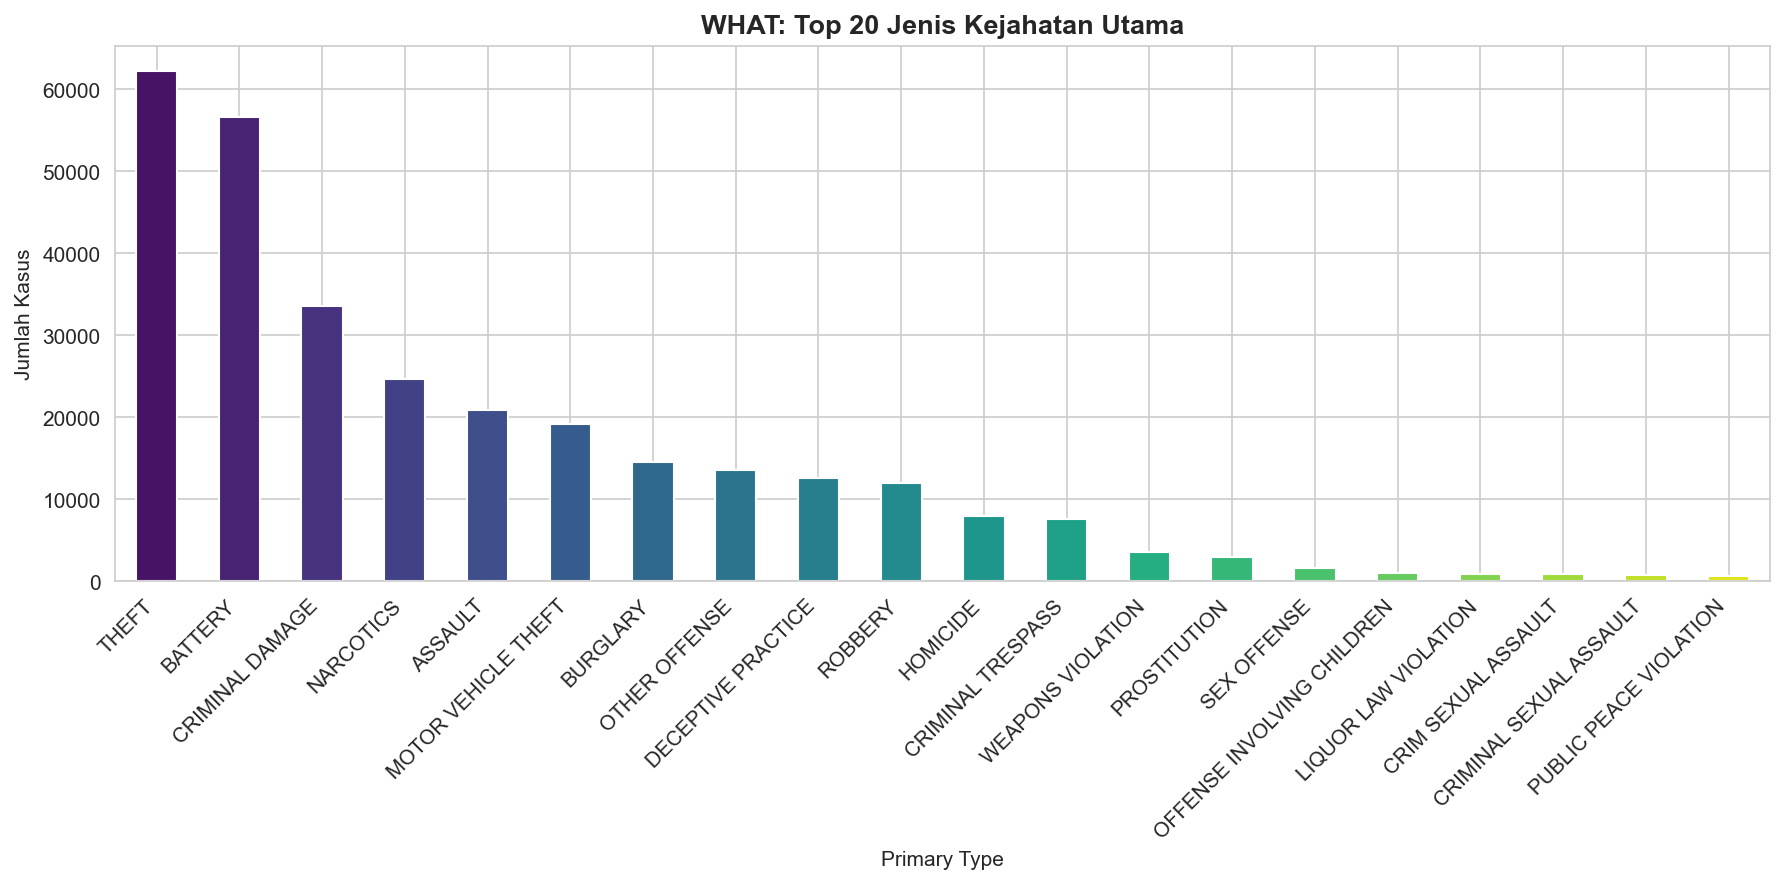

In [3]:
print("\n[1.1] Top 20 Jenis Kejahatan Utama (Primary Type):")
primary_dist = df['Primary Type'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
primary_dist.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 20))
ax.set_title('WHAT: Top 20 Jenis Kejahatan Utama', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Kasus')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT}/what_01_primary_type.png', bbox_inches='tight')
plt.show()


[1.2] Top 15 Deskripsi Kejahatan (Description):


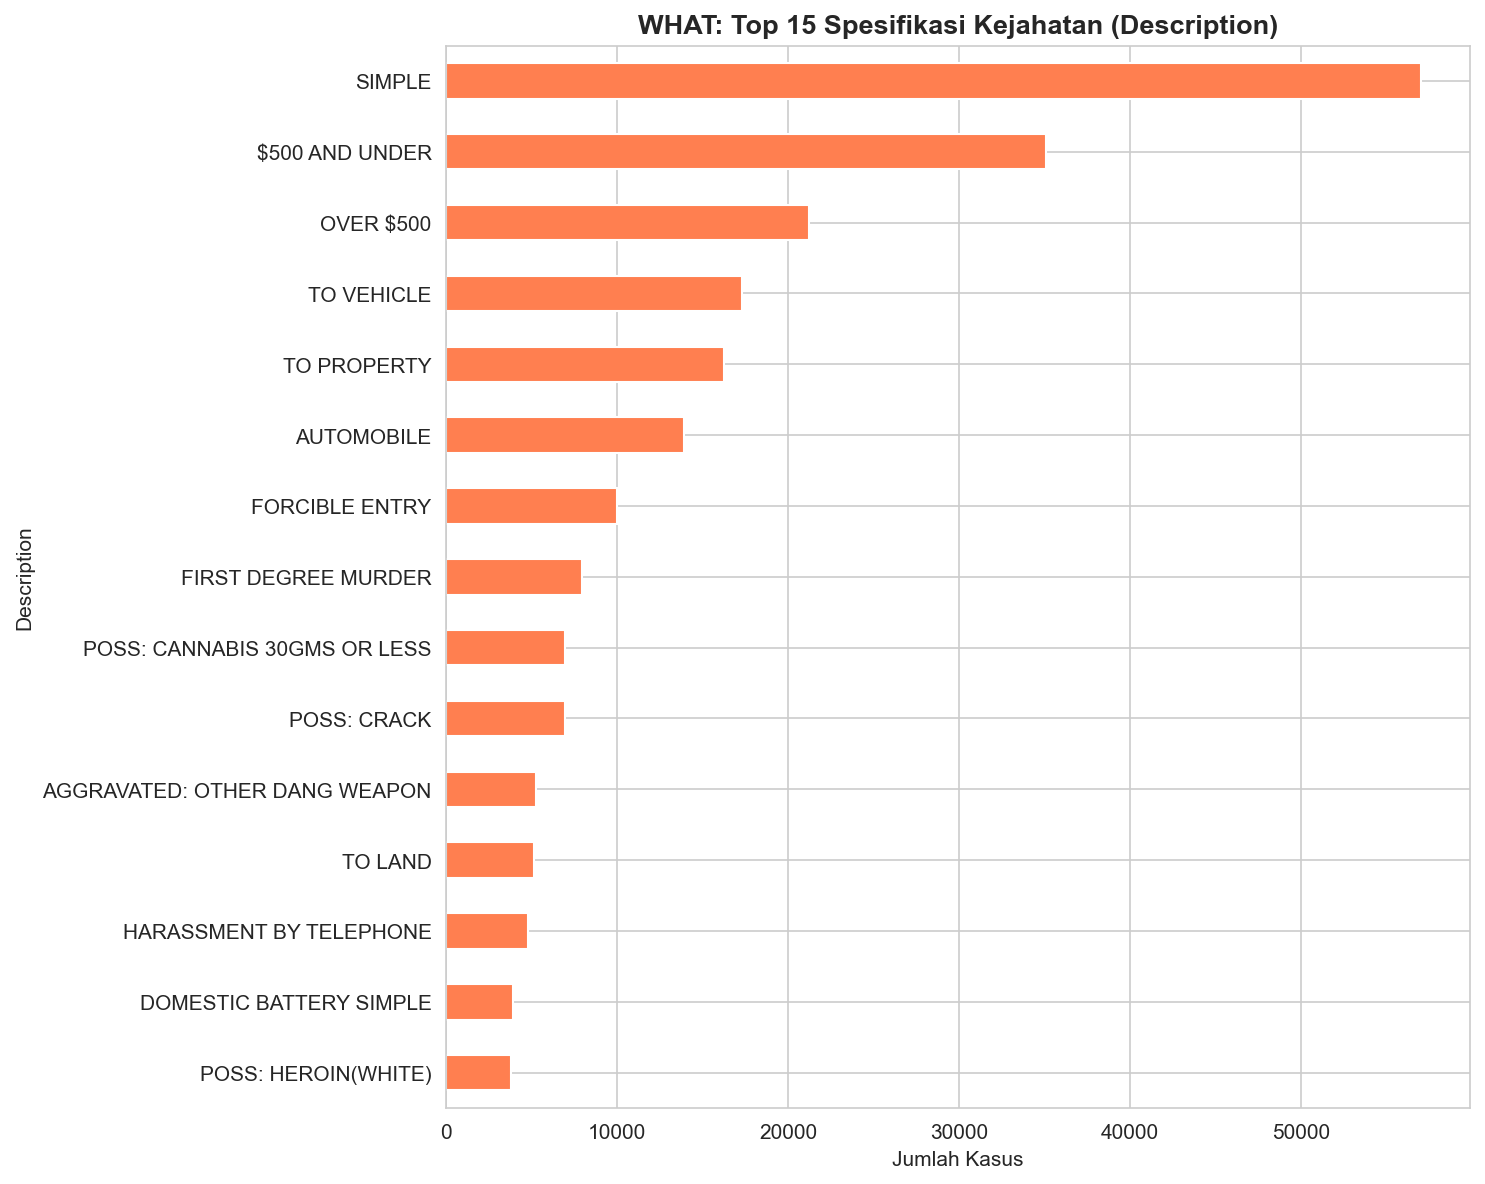

In [4]:
print("\n[1.2] Top 15 Deskripsi Kejahatan (Description):")
desc_dist = df['Description'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 8))
desc_dist.sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('WHAT: Top 15 Spesifikasi Kejahatan (Description)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Kasus')
plt.tight_layout()
plt.savefig(f'{OUT}/what_02_description.png', bbox_inches='tight')
plt.show()


[1.3] Proporsi Kejahatan Domestik vs Non-Domestik:


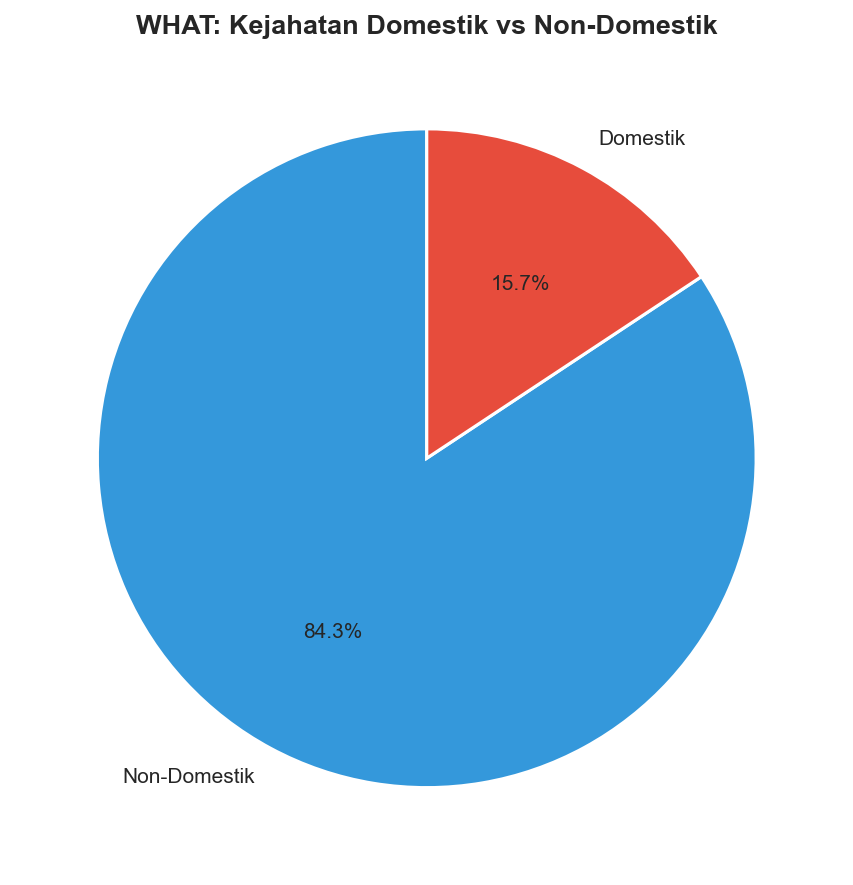

In [6]:
print("\n[1.3] Proporsi Kejahatan Domestik vs Non-Domestik:")
# Beberapa format data mungkin menggunakan boolean True/False atau string 'True'/'False'
# Kita tangani keduanya dengan aman:
dom_dist = df['Domestic'].replace({True: 'Domestik', False: 'Non-Domestik',
                                   'True': 'Domestik', 'False': 'Non-Domestik',
                                   'true': 'Domestik', 'false': 'Non-Domestik'}).value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(dom_dist, labels=dom_dist.index, autopct='%1.1f%%', 
       colors=['#3498db', '#e74c3c'], startangle=90, 
       wedgeprops=dict(edgecolor='w', linewidth=1.5))
ax.set_title('WHAT: Kejahatan Domestik vs Non-Domestik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/what_03_domestic.png', bbox_inches='tight')
plt.show()


[1.4] Heatmap Top 5 Kejahatan Utama x Domestik/Non-Domestik:


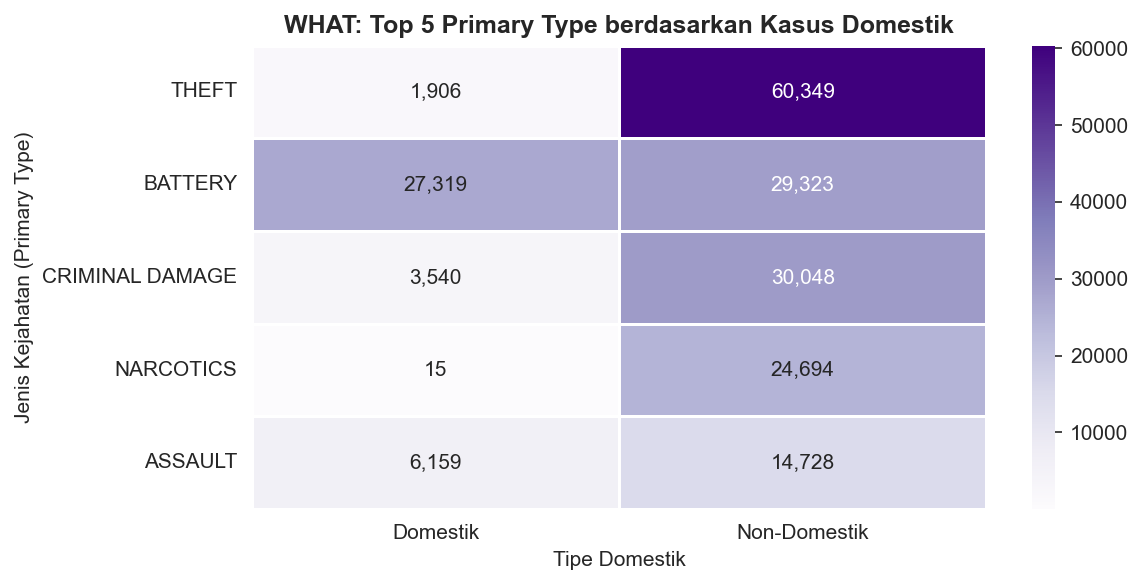

  [Saved] what_01 ~ what_04


In [7]:
print("\n[1.4] Heatmap Top 5 Kejahatan Utama x Domestik/Non-Domestik:")
top5_crime = df['Primary Type'].value_counts().head(5).index

df_temp = df.copy()
df_temp['Domestic_Label'] = df_temp['Domestic'].replace({True: 'Domestik', False: 'Non-Domestik', 
                                                         'True': 'Domestik', 'False': 'Non-Domestik'})
ct_dom = pd.crosstab(df_temp[df_temp['Primary Type'].isin(top5_crime)]['Primary Type'],
                     df_temp['Domestic_Label'])
ct_dom = ct_dom.reindex(index=top5_crime)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(ct_dom, annot=True, fmt=',.0f', cmap='Purples', ax=ax, linewidths=0.5)
ax.set_title('WHAT: Top 5 Primary Type berdasarkan Kasus Domestik', fontsize=12, fontweight='bold')
ax.set_ylabel('Jenis Kejahatan (Primary Type)'); ax.set_xlabel('Tipe Domestik')
plt.tight_layout()
plt.savefig(f'{OUT}/what_04_primary_domestic.png', bbox_inches='tight')
plt.show()
print("  [Saved] what_01 ~ what_04")